# Tutorial for *BiLO: Bi-Level Local Operator for PDE inverse problem. Part II, Efficient Bayesian Inverse Problem*

## PDE Bayesian Inverse Problem

Consider a PDE that depends on some parameter $\theta$:
$$
\quad F(D^ku,\cdots, Du, u, \theta) = 0
$$

Given some observational data that depends on the solution $u$, we want to infer the posterior distribution $P(\theta|\rm{Data})$, which is given by Bayes' theorem:
$$
P(\theta|\rm{Data}) \propto P(\rm{Data}|\theta)P(\theta)
$$


The potential energy function is defined as:
$$
U(\theta) = -\log P(\rm{Data}|\theta) - \log P(\theta)
$$

We want to sample from the posterior distribution $\exp\{-U(\theta)\}$ using Markov Chain Monte Carlo (MCMC) methods.


## Bi-Level local Operator Learning (BiLO) for PDE Bayesian Inverse Problem

We solve the following bi-level problem
$$\begin{aligned}
& \theta \sim \exp\{-U[u(\cdot,\theta;W^*(\theta))]\} \\
&W^*(\theta) = \arg\min_{W} \quad \|F(u(\cdot,\theta;W),\theta)\|^2 + \|d_\theta F(u(\cdot,\theta;W),\theta)\|^2 \\
\end{aligned}$$

At the upper level, we sample $\theta$ from the posterior distribution using gradient-based MCMC. At the lower level, for each $\theta$, we minimize the residual loss and the residual-gradient loss with respect to the network weights $W$.


## Example


In this example, we solve the following PDE inverse problem in Bayesian framework. The PDE is given by:

$$
D u'' = f, \quad u(0) = 0, \quad u(1) = 0
$$

where $f = - \pi^2 \sin(\pi x)$. $D$ is an unknown PDE parameter. In this example, the full solution operator is $u(x,D) = \sin(\pi x)/D$. Suppose the ground truth parameter is $D_{gt}$. 

We observe the data $\hat{u}_i = u(x_i, D_{gt}) + \epsilon_i$ at $N$ points $x_i \in [0,1]$, where $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$ is Gaussian noise. The likelihood is given by:

$$
  P(Data|D) = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left( -\frac{1}{2\sigma^2} \left| u(x_i,D) - \hat{u}_i\right|^2 \right)
$$

The prior distribution of $P(D)$ is [Gamma distribution](https://en.wikipedia.org/wiki/Gamma_distribution) with shape parameter $\alpha=2$ and rate parameter $\lambda=1$. 

In [56]:
import sys
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# set seed
torch.manual_seed(0)

In [57]:
class DenseNet(nn.Module):
    '''General class for a dense neural network with a variable number of layers and width.'''
    def __init__(self, depth=4, width=64, 
                 output_transform=lambda x, u: u):
        super(DenseNet, self).__init__()
        input_dim = 1
        output_dim = 1
        self.width = width
        self.depth = depth
        self.activation = torch.tanh
        layers = []

        # input layer/embedding layer
        self.input_layer = nn.Linear(input_dim, width)

        # hidden layers (depth - 2)
        self.hidden_layers = nn.ModuleList([nn.Linear(width, width) for _ in range(depth - 2)])
        self.output_layer = nn.Linear(width, output_dim)
        
        # Store the output transformation function
        self.output_transform = output_transform
    

    def forward(self, x):
        # Define the forward pass
        act = self.activation
        u = act(self.input_layer(x))
        for layer in self.hidden_layers:
            u = act(layer(u))
        u = self.output_layer(u)
        
        return self.output_transform(x, u)


In [58]:
def prior(x):
    '''
    Prior distribution P(x).
    Gamma distribution with shape alpha and rate lambda. Following wikipedia notation.
    '''
    alpha = 2 # shape
    lmbd = 1 # rate
    prior = (lmbd**alpha / torch.exp(torch.lgamma(torch.tensor(alpha)))) * (x**(alpha - 1)) * torch.exp(-lmbd * x)
    return prior

In [59]:
class ScalarPoisson():
    ''' 
    Class for the scalar Poisson equation D u_xx = f(x) on the domain [0, 1] with Dirichlet boundary conditions.
    '''
    def __init__(self, D = 1.0, sigma = 0.1):
        self.D = D
        self.sigma = sigma
        self.dataset = {}
    
    def f(self, x):
        ''' Forcing term'''
        return -(torch.pi)**2 * torch.sin(torch.pi * x)

    def u_exact(self, x, D):
        ''' Exact PDE solution for given D '''
        return torch.sin(torch.pi * x) / D
    
    def get_dataset(self, D0, N_res_train, N_dat_train, N_res_test, N_dat_test, nz_std = None):
        ''' Generate data and collocations points for training.'''
        
        self.D0 = D0
        self.dataset['D0'] = self.D0
        self.dataset['D'] = self.D

        self.N_res_train = N_res_train
        self.N_dat_train = N_dat_train
        self.N_res_test = N_res_test
        self.N_dat_test = N_dat_test

        # Collocation points for residual loss
        self.dataset['x_res_train'] = torch.linspace(0, 1, N_res_train).view(-1, 1)
        self.dataset['x_res_test'] = torch.linspace(0, 1, N_res_test).view(-1, 1)

        # Collocation points for data loss
        self.dataset['x_dat_test'] = torch.linspace(0, 1, N_dat_test).view(-1, 1)
        self.dataset['x_dat_train'] = torch.linspace(0, 1, N_dat_train).view(-1, 1)
        
        # use exact D for testing
        self.dataset['ugt_dat_test'] = self.u_exact(self.dataset['x_dat_test'], self.D)

        # use D0 for pre-training
        self.dataset['u0_dat_train'] = self.u_exact(self.dataset['x_dat_train'], self.D0)

        # u at ground truth D
        u = self.u_exact(self.dataset['x_dat_train'], self.D)

        # add noise to the data if nz_std is not None
        if nz_std is None:
            noise = 0
        else:
            noise = torch.randn_like(u) * nz_std
        
        # (noisy) data for bayesian inference
        self.dataset['u_dat_train'] = u + noise    

In [60]:
n_res_train = 11
n_dat_train = 11
n_res_test = 101
n_dat_test = 101
nz_std = 0.2
D_gt = 1.0 # ground truth D
D0 = 2.0 # initial guess for D
pde = ScalarPoisson(D=D_gt, sigma=nz_std)
pde.get_dataset(D0, n_res_train, n_dat_train, n_res_test, n_dat_test, nz_std=nz_std)

Visualize the dataset

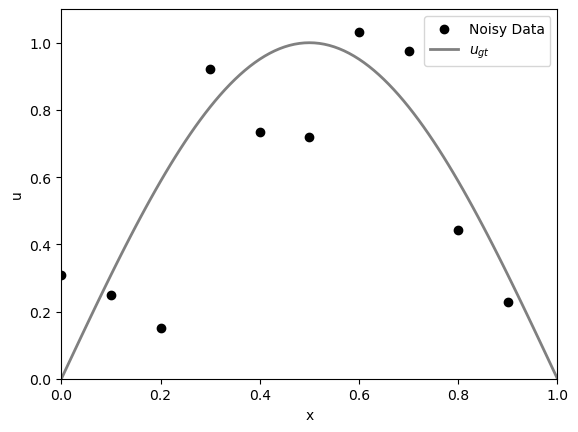

In [61]:
plt.scatter(pde.dataset['x_dat_train'], pde.dataset['u_dat_train'], label='Noisy Data', color='black')
plt.plot(pde.dataset['x_dat_test'], pde.u_exact(pde.dataset['x_dat_test'], D_gt), label='$u_{gt}$', color='gray', linewidth=2)
plt.xlabel('x')
plt.ylabel('u')
plt.xlim(0, 1)
plt.ylim(0, 1.1)
plt.legend()

In [62]:
class LocalOperator(DenseNet):
    '''Represent u(x, D; W), where W is the neural network weights.'''
    def __init__(self, fdepth=4, fwidth=64, 
                 output_transform=lambda x, u: u):
        super().__init__(fdepth, fwidth, output_transform)

        # embedding layer
        self.param_embeddings = nn.Linear(1, self.width, bias=True)
        # set requires_grad to False
        for embedding_weights in self.param_embeddings.parameters():
            embedding_weights.requires_grad = False
        
        self.params_expand = None

    def embedding(self, x, z):
        '''
        Embedding layer for the coordinate x and PDE parameter z.
        This layer compute y = Wx + b + Rz, where R is a fixed embedding matrix.
        '''
        y = self.input_layer(x) 

        # expand the parameter to the same size as x
        self.params_expand = z.expand(x.shape[0], -1)
        param_embedding = self.param_embeddings(self.params_expand)
        y += param_embedding
        return y

    def forward(self, x , z):
        '''
        Forward pass of the network.
        '''
        X = self.embedding(x, z)
        X = self.activation(X)
        for layer in self.hidden_layers:
            X = self.activation(layer(X))
        u = self.output_layer(X)
        
        return self.output_transform(x, u)

In [63]:
class Bilo(nn.Module):
    '''
    Define the loss functions
    '''
    def __init__(self, localOp, pde):
        super(Bilo, self).__init__()
        
        self.localOp = localOp
        self.pde = pde
        self.dataset = pde.dataset

        # initial D
        D0 = pde.dataset['D0']

        # initialize D as a learnable parameter
        self.D = nn.Parameter(torch.tensor([[D0]]), requires_grad=True)

        # collection of network weights (W)
        self.param_net = [v for v in self.localOp.parameters() if v.requires_grad]

        # collection of PDE parameters (theta)
        self.param_pde = [self.D]
        
        # weight for residual-gradient loss
        self.wresgrad = 0.1

        # tolerance for lower level loop
        self.tol_lower = 1e-2

        # lower level optimizer for network weights
        self.optimizer_lower = torch.optim.Adam(self.param_net, lr=1e-3)

    def residual_grad_loss(self):
        ''' compute residual loss and residual-gradient loss'''
        x = self.dataset['x_res_train']
        x.requires_grad = True
        u = self.localOp(x, self.D)

        # compute the PDE residual
        u_x = torch.autograd.grad(u, x,
            create_graph=True, retain_graph=True, grad_outputs=torch.ones_like(u))[0]
        u_xx = torch.autograd.grad(u_x, x,
            create_graph=True, retain_graph=True, grad_outputs=torch.ones_like(u_x))[0]
        res = self.localOp.params_expand * u_xx - self.pde.f(x)

        # compute the gradient of the residual with respect to the parameters
        resgrad = torch.autograd.grad(res, self.localOp.params_expand, grad_outputs=torch.ones_like(res),
        create_graph=True, allow_unused=True)[0]
        
        # compute the loss
        res_loss = torch.mean(res**2)
        res_grad_loss = torch.mean(resgrad**2)
        
        return  res_loss, res_grad_loss
    
    def pretrain_data_loss(self):
        ''' 
        Compute the data loss for pretraining, 
        This loss speed up pre-training but is optional. 
        '''
        x = self.dataset['x_dat_train']
        u = self.localOp(x, self.D)
        u_dat = self.dataset['u0_dat_train']

        loss = torch.mean((u - u_dat)**2)
        return loss

    def potential_energy(self):
        ''' Potential energy '''
        x  = self.dataset['x_dat_train']
        u  = self.localOp(x, self.D)
        sigma = self.pde.sigma
        u_dat = self.dataset['u_dat_train']
        # negative log likelihood
        U = torch.sum((u - u_dat)**2)/ (2 * sigma**2)
        # negative log prior
        log_prior = -torch.log(prior(self.D))

        return U

    def pretrain(self, max_iter):
        '''
        Fix the D and pretrain the local operator for max_iter steps.
        '''
        optimizer = torch.optim.Adam(self.localOp.parameters(), lr=1e-3)
        for step in range(max_iter):
            optimizer.zero_grad()
            res_loss, resgrad_loss = self.residual_grad_loss()
            # data_loss = self.pretrain_data_loss()
            total_loss = res_loss + self.wresgrad * resgrad_loss
            total_loss.backward()
            optimizer.step()
            if step % 100 == 0:
                print(f'Step {step}, res_loss: {res_loss.item():.3e}, resgrad_loss: {resgrad_loss.item():.3e}, D: {self.D.item():.3f}')

    def lower_level_loop(self, D):  
        '''
        Solve lower level optimization problem for the network weights given D.
        '''
        with torch.no_grad():
            self.D.copy_(D)

        net_loss = float('inf')
        step = 0
        while net_loss > self.tol_lower and step < 1000:

            res_loss, resgrad_loss = self.residual_grad_loss()
            
            net_loss = res_loss + resgrad_loss * self.wresgrad

            grads_net = torch.autograd.grad(net_loss, self.param_net)
            for i, param in enumerate(self.param_net):
                param.grad = grads_net[i]
            
            self.optimizer_lower.step()
            step += 1
            print(f'lower {step}, net_loss: {net_loss.item():.3e}, res_loss: {res_loss.item():.3e}, resgrad_loss: {resgrad_loss.item():.3e}, D: {self.D.item():.3f}')

## Pre-training (Initialization)

In the pre-training step, we start with initial guess $D_0$ and learn the local operator $u(x,D_0;W)$ at fixed $D_0$.

In [64]:
localop = LocalOperator(output_transform=lambda x, u: u * (1 - x)*x)
bilo = Bilo(localop, pde)
max_iter = 1000
bilo.pretrain(max_iter)

Step 0, res_loss: 4.064e+01, resgrad_loss: 1.452e-02, D: 2.000
Step 100, res_loss: 8.578e-02, resgrad_loss: 2.440e+00, D: 2.000
Step 200, res_loss: 3.010e-03, resgrad_loss: 4.349e-02, D: 2.000
Step 300, res_loss: 3.273e-04, resgrad_loss: 4.983e-03, D: 2.000
Step 400, res_loss: 2.124e-04, resgrad_loss: 1.500e-03, D: 2.000
Step 500, res_loss: 2.030e-04, resgrad_loss: 7.190e-04, D: 2.000
Step 600, res_loss: 1.914e-04, resgrad_loss: 5.209e-04, D: 2.000
Step 700, res_loss: 1.777e-04, resgrad_loss: 4.487e-04, D: 2.000
Step 800, res_loss: 1.633e-04, resgrad_loss: 4.063e-04, D: 2.000
Step 900, res_loss: 1.492e-04, resgrad_loss: 3.744e-04, D: 2.000


In [65]:
# saving and reloading, for development
# torch.save(bilo.state_dict(), 'bilo_weights.pth')

# localop = LocalOperator(output_transform=lambda x, u: u * (1 - x)*x)
# bilo = Bilo(localop, pde)
# bilo.load_state_dict(torch.load('bilo_weights.pth'))

## Fine-Tuning (Sampling)

In the fine-tuning step, we will use the Hamiltonian Monte Carlo (HMC) with leapfrog integrator to sample posterior distribution of the PDE parameter $\theta$. The key modification to HMC is that we need to solve the lower level problem whenever $\theta$ is updated.



### BiLO-HMC Algorithm

**Requires:** Initial state $\theta^{(0)}$, time step size $\delta t$, number of leapfrog steps $L$, number of samples $N$.

For $k = 0, 1, \dots, N-1$:
- Sample momentum $r \sim \mathcal{N}(0, M)$.
- Set $(\theta_0, r_0) = (\theta^{(k)}, r)$.
- Compute initial Hamiltonian: $H_0 = H(\theta_0, r_0; W)$.
- Run $\texttt{LowerLevelIteration}(\theta_0)$ to optimize network weights for current parameter.
- **Leapfrog Integration:**  
   For $i = 0, 1, \dots, L-1$:
   - $r_{i+1/2} = r_i - \frac{\delta t}{2} \nabla_\theta U(\theta_i, W)$
   - $D_{i+1} = D_i + \delta t M^{-1} r_{i+1/2}$
   - Run $\texttt{LowerLevelIteration}(\theta_{i+1})$
   - $r_{i+1} = r_{i+1/2} - \frac{\delta t}{2} \nabla_\theta U(\theta_{i+1}, W)$
- Compute final Hamiltonian: $H_L = H(\theta_L, r_L; W)$
- Calculate acceptance probability:  
   $\alpha = \min\left(1, \exp(H_0 - H_L)\right)$
- With probability $\alpha$, set $\theta^{(k+1)} = \theta_L$; otherwise, set $\theta^{(k+1)} = \theta^{(k)}$.


### Low-Rank Adaptation (LoRA)

We need to solve the lower level problem for each new parameter $\theta$. 
For simplicity, this tutorial uses full fine-tuning. 
For large neural networks, we can use LoRA to reduce the number of parameters to be updated, as demonstrated in the manuscript.

In [66]:
def hmc(bilo, max_iter, dt=1e-3, L=10, warmup_steps=10):
    """
    BiLO - HMC sampler.
    """
    total_accept = 0
    
    # Initial position is the current parameter D
    D_current = bilo.D.data.clone()

    # Collect samples
    D_samples = []
    u_samples = []

    x_test = bilo.dataset['x_dat_test']

    for step in range(max_iter):
        
        bilo.lower_level_loop(D_current)

        # --- HMC Step ---
        theta = D_current.clone()
        theta0 = D_current.clone()
        
        # Sample momentum from a standard normal distribution
        r = torch.randn_like(theta)
        
        # Evaluate potential and kinetic energy at the current state
        U_0 = bilo.potential_energy()
        K_0 = torch.sum(r**2) / 2
                
        # First half-step for momentum
        grad_U = torch.autograd.grad(U_0, bilo.D)[0]
        r -= 0.5 * dt * grad_U
        
        # Full steps for position and momentum
        for _ in range(L):
            # Full step for position
            theta += dt * r
            
            # Lower level optimization
            bilo.lower_level_loop(theta)
            
            # Full step for momentum
            U = bilo.potential_energy()
            grad_U = torch.autograd.grad(U, bilo.D)[0]
            r -= dt * grad_U

        # Final half-step for momentum (using the last computed gradient)
        r -= 0.5 * dt * grad_U
        
        # --- Metropolis-Hastings Acceptance ---
        # Evaluate potential and kinetic energy at the proposed state
        U_L = U
        K_L = torch.sum(r**2) / 2
        
        # Calculate acceptance probability
        alpha = torch.exp(U_0 - U_L + K_0 - K_L)

        accepted = False
        if torch.rand(1) < alpha:
            # Accept the proposal
            D_current = theta
            total_accept += 1
            accepted = True
        
        print(f'Step {step}, D_current: {theta0.item():.3f}, D_propose: {theta.item():.3f}, acc prob: {alpha.item():.3e}, accepted: {accepted}')

        # Store the (potentially new) current state
        if step > warmup_steps:
            D_samples.append(D_current.item())
        
            # Store the corresponding solution u(x) for visualization
            with torch.no_grad():
                bilo.D.copy_(D_current)
                u_current = bilo.localOp(x_test, bilo.D)
                u_samples.append(u_current.detach().cpu().numpy())


    acc_rate = total_accept / max_iter
    print(f'Acceptance rate: {acc_rate:.3f}')
    return D_samples, u_samples


In [67]:
D_samples, u_samples = hmc(bilo, 200, dt=0.01, L=10)

lower 1, net_loss: 1.707e-04, res_loss: 1.358e-04, resgrad_loss: 3.487e-04, D: 2.000
lower 1, net_loss: 6.582e-02, res_loss: 6.318e-02, resgrad_loss: 2.644e-02, D: 2.001
lower 2, net_loss: 4.311e-01, res_loss: 4.225e-01, resgrad_loss: 8.592e-02, D: 2.001
lower 3, net_loss: 3.045e-02, res_loss: 2.987e-02, resgrad_loss: 5.791e-03, D: 2.001
lower 4, net_loss: 1.402e-01, res_loss: 1.367e-01, resgrad_loss: 3.459e-02, D: 2.001
lower 5, net_loss: 2.415e-01, res_loss: 2.344e-01, resgrad_loss: 7.065e-02, D: 2.001
lower 6, net_loss: 7.649e-02, res_loss: 7.540e-02, resgrad_loss: 1.087e-02, D: 2.001
lower 7, net_loss: 2.120e-02, res_loss: 2.029e-02, resgrad_loss: 9.102e-03, D: 2.001
lower 8, net_loss: 1.226e-01, res_loss: 1.188e-01, resgrad_loss: 3.789e-02, D: 2.001
lower 9, net_loss: 1.353e-01, res_loss: 1.306e-01, resgrad_loss: 4.658e-02, D: 2.001
lower 10, net_loss: 4.588e-02, res_loss: 4.346e-02, resgrad_loss: 2.424e-02, D: 2.001
lower 11, net_loss: 1.590e-03, res_loss: 1.485e-03, resgrad_loss

## Reference Posterior

In this example, since we know the analytical full solution operator, we can compute the posterior distribution of $D$ with high accuracy using numerical integration. This serves as a reference posterior distribution for evaluating the BiLO-HMC.

In [68]:
def posterior_energy(D):
    '''Compute the posterior for a given D.'''
    x = pde.dataset['x_dat_train']
    u_dat = pde.dataset['u_dat_train']

    u = pde.u_exact(x, D)
    sigma = torch.tensor(pde.sigma)
    p = 1/torch.sqrt(2 * torch.pi * sigma**2) * torch.exp(-0.5 * torch.sum((u - u_dat)**2) / pde.sigma**2)
    P_likelihood = torch.prod(p)

    P_prior = prior(D)

    return P_likelihood * P_prior

D_grid = torch.linspace(0.00, 10, 1000)
posterior = torch.zeros_like(D_grid)
x = pde.dataset['x_dat_test']
u = torch.zeros(len(D_grid), len(x))

for i, D in enumerate(D_grid):
    if i==0:
        # Avoid division by zero at D=0
        posterior[i] = 0
        continue
    posterior[i] = posterior_energy(D)
    u[i, :] = pde.u_exact(x, D).view(-1)

# normalize the posterior
integral = torch.trapz(posterior, D_grid)
posterior /= integral

# compute integral and standard deviation of u
u_mean = torch.trapz(u * posterior.view(-1, 1), D_grid, dim=0)
u_std = torch.sqrt(torch.trapz((u - u_mean.view(1, -1))**2 * posterior.view(-1, 1), D_grid, dim=0))

## Results

### Visualization of Posterior Distribution of the PDE parameter
Here we compare the posterior of $D$ obtained from BiLO-HMC with the reference posterior computed using the known solution operator.

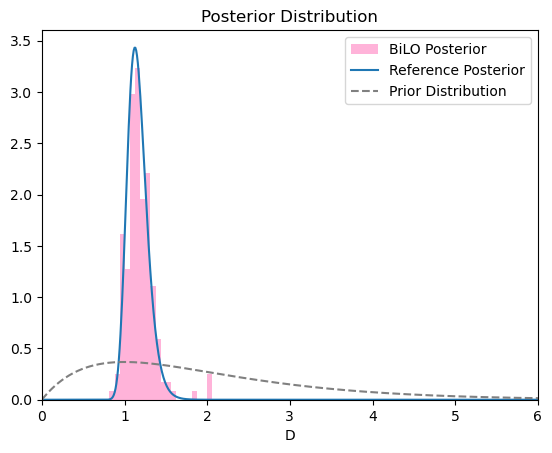

In [69]:
prior_D = prior(D_grid)

# histogram of bilo. theta_samples
plt.hist(D_samples, bins=20, density=True, alpha=0.5, label='BiLO Posterior',color='#FF69B4')
plt.plot(D_grid.numpy(), posterior.numpy(), label='Reference Posterior', color='#1f77b4')
plt.plot(D_grid.numpy(), prior_D.numpy(), label='Prior Distribution', linestyle='--',color='gray')
plt.xlabel('D')
plt.title('Posterior Distribution')
plt.xlim(0, 6)
plt.legend()

### Visualize the posterior distribution of PDE solution

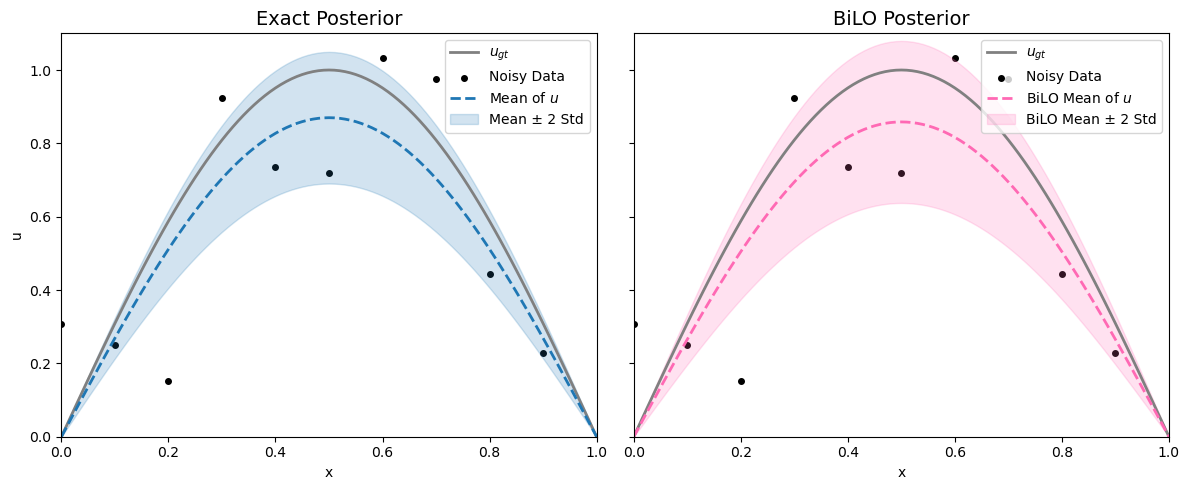

In [70]:
u_sample = np.concatenate(u_samples, axis=1)
u_mean_bilo = u_sample.mean(axis=1)
u_std_bilo = u_sample.std(axis=1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Reference Posterior of u
axs[0].plot(pde.dataset['x_dat_test'], pde.u_exact(pde.dataset['x_dat_test'], D_gt), color='gray', linewidth=2, label='$u_{gt}$')
axs[0].scatter(pde.dataset['x_dat_train'], pde.dataset['u_dat_train'], color='black', s=16, label='Noisy Data')
axs[0].plot(pde.dataset['x_dat_test'], u_mean, linestyle='--', color='#1f77b4', linewidth=2, label='Mean of $u$')
axs[0].fill_between(
    pde.dataset['x_dat_test'].view(-1).numpy(),
    (u_mean - 2*u_std),
    (u_mean + 2*u_std),
    color='#1f77b4', alpha=0.2, label='Mean ± 2 Std'
)
axs[0].set_title('Exact Posterior', fontsize=14)
axs[0].set_xlabel('x')
axs[0].set_ylabel('u')
axs[0].legend(fontsize=10, loc='upper right')
axs[0].set_xlim(0, 1)
axs[0].set_ylim(0, 1.1)
   

# BiLO posterior of u
axs[1].plot(pde.dataset['x_dat_test'], pde.u_exact(pde.dataset['x_dat_test'], D_gt), color='gray', linewidth=2, label='$u_{gt}$')
axs[1].scatter(pde.dataset['x_dat_train'], pde.dataset['u_dat_train'], color='black', s=16, label='Noisy Data')
axs[1].plot(pde.dataset['x_dat_test'], u_mean_bilo, linestyle='--', color='#FF69B4', linewidth=2, label='BiLO Mean of $u$')
axs[1].fill_between(
    pde.dataset['x_dat_test'].view(-1).numpy(),
    (u_mean_bilo - 2*u_std_bilo),
    (u_mean_bilo + 2*u_std_bilo),
    color="#FF69B4", alpha=0.2, label='BiLO Mean ± 2 Std'
)
axs[1].set_title('BiLO Posterior', fontsize=14)
axs[1].set_xlabel('x')
axs[1].legend(fontsize=10, loc='upper right')
axs[1].set_xlim(0, 1)
axs[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()